In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

In [2]:
data = {
    'hours_studied': [2,4,6,8,1,3,7,9,5,2,6,8,4,7,1],
    'attendance': [60,65,80,90,50,55,85,95,70,58,82,91,67,88,45],
    'marks': [35,40,55,78,25,30,70,90,50,38,65,85,45,72,20],
    'pass': [0,0,1,1,0,0,1,1,1,0,1,1,0,1,0]
}

df = pd.DataFrame(data)
df.head()

,hours_studied,attendance,marks,pass
0,2,60,35,0
1,4,65,40,0
2,6,80,55,1
3,8,90,78,1
4,1,50,25,0


In [4]:
X = df[['hours_studied', 'attendance', 'marks']]
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [6]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [7]:
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


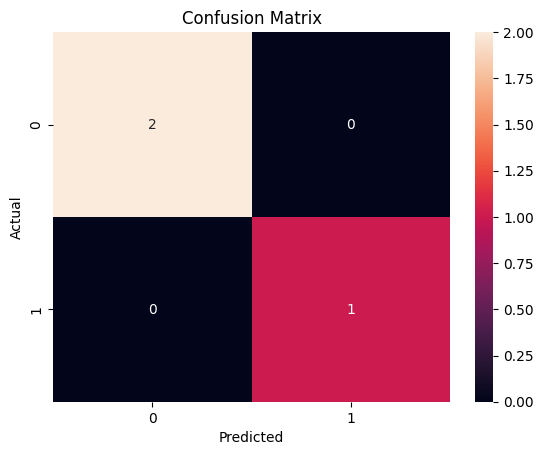

In [8]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

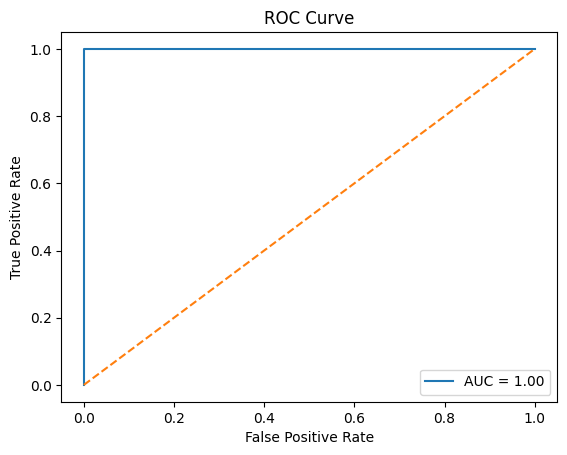

In [9]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()